# Combined Dataset Exploratory Data Analysis & Hypotheses


In [1]:
import pandas as pd

In [2]:
df_encoded = pd.read_csv('../../../data/processed/churn_prediction_dataset.csv')
print(f'Loaded dataset: {df_encoded.shape}')

Loaded dataset: (78325, 189)


In [3]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, mannwhitneyu, spearmanr, kruskal
import warnings
warnings.filterwarnings('ignore')

## 3.1 Data Overview

In [4]:
print('='*80)
print('SECTION 1: DATA OVERVIEW')
print('='*80)

df = df_encoded.copy()

print(f'\nDataset Shape: {df.shape}')
print(f'Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}')

# Separate column types
bool_cols = df.select_dtypes(include=['bool']).columns.tolist()
int_cols = df.select_dtypes(include=['int64']).columns.tolist()
float_cols = df.select_dtypes(include=['float64']).columns.tolist()
numeric_non_ohe = [c for c in int_cols + float_cols if c not in bool_cols]

print(f'\nColumn Type Breakdown:')
print(f'  Float64 (continuous):  {len(float_cols)}')
print(f'  Int64 (discrete/encoded): {len(int_cols)}')
print(f'  Bool (one-hot encoded):   {len(bool_cols)}')
print(f'  Total numeric (non-OHE):  {len(numeric_non_ohe)}')

# Target variable
print(f'\n--- TARGET: prospect_outcome ---')
target_counts = df['prospect_outcome'].value_counts()
print(f'  Won (1):     {target_counts.get(1, 0):,}  ({target_counts.get(1,0)/len(df)*100:.1f}%)')
print(f'  Churned (0): {target_counts.get(0, 0):,}  ({target_counts.get(0,0)/len(df)*100:.1f}%)')
print(f'  Churn Rate:  {(df["prospect_outcome"]==0).mean()*100:.2f}%')

# Null check
nulls = df.isnull().sum()
print(f'\nMissing Values: {nulls.sum()} total across all columns')

SECTION 1: DATA OVERVIEW

Dataset Shape: (78325, 189)
Rows: 78,325  |  Columns: 189

Column Type Breakdown:
  Float64 (continuous):  18
  Int64 (discrete/encoded): 58
  Bool (one-hot encoded):   113
  Total numeric (non-OHE):  76

--- TARGET: prospect_outcome ---
  Won (1):     68,967  (88.1%)
  Churned (0): 9,358  (11.9%)
  Churn Rate:  11.95%

Missing Values: 0 total across all columns


In [5]:
print('\n' + '='*80)
print('SECTION 2: FEATURE ENGINEERING')
print('='*80)

# 2a. Price Change Features
df['price_change'] = df['total_amount'] - df['last_years_price']
df['price_change_pct'] = np.where(
    df['last_years_price'] > 0,
    (df['total_amount'] - df['last_years_price']) / df['last_years_price'] * 100,
    0
)
df['price_increase_flag'] = (df['price_change'] > 0).astype(int)
print('Created: price_change, price_change_pct, price_increase_flag')

# 2b. Sentiment Delta (CC calls)
df['cc_sentiment_delta'] = df['cc_contractor_sentiment_end_score'] - df['cc_contractor_sentiment_start_score']
df['cc_sentiment_improved'] = (df['cc_sentiment_delta'] > 0).astype(int)
df['cc_sentiment_declined'] = (df['cc_sentiment_delta'] < 0).astype(int)
print('Created: cc_sentiment_delta, cc_sentiment_improved, cc_sentiment_declined')

# 2c. Composite Risk Scores
# Complaint intensity
df['complaint_intensity'] = (
    df['serious_complaint'] + 
    df['other_complaint'] + 
    df['cc_contractor_complained'] + 
    df['crm_customer_complained']
)
print('Created: complaint_intensity (sum of complaint indicators)')

# Dissatisfaction composite
df['dissatisfaction_composite'] = (
    df['cc_dissatisfaction_time_to_complete'] +
    df['cc_dissatisfaction_support'] +
    df['cc_process_complexity_concerns'] +
    df['cc_platform_issues']
)
print('Created: dissatisfaction_composite')

# Competitive pressure score
df['competitive_pressure'] = (
    df['explicit_competitor_mention'] +
    df['mentioned_competitors'] +
    df['price_switching_mentioned']
)
print('Created: competitive_pressure')

# 2d. Payment behaviour
df['payment_delay_flag'] = (df['payment_timeframe'] < 0).astype(int)
df['abs_payment_timeframe'] = df['payment_timeframe'].abs()
print('Created: payment_delay_flag, abs_payment_timeframe')

# 2e. Pricing tier (from total_amount)
df['pricing_tier'] = pd.qcut(df['total_amount'], q=4, labels=['Low', 'Mid-Low', 'Mid-High', 'High'])
df['pricing_tier_encoded'] = df['pricing_tier'].cat.codes
print('Created: pricing_tier, pricing_tier_encoded')

# 2f. Tenure-price interaction
df['tenure_price_ratio'] = df['total_amount'] / (df['tenure_years'] + 1)
print('Created: tenure_price_ratio')

# 2g. Score gap (current vs release)
df['score_gap'] = df['total_renewal_score_new'] - df['renewal_score_at_release']
print('Created: score_gap (difference between current and release renewal scores)')

# 2h. Net revenue components ratio
df['pqq_share'] = np.where(
    df['total_amount'] > 0,
    df['pqqnet'] / df['total_amount'],
    0
)
df['package_share'] = np.where(
    df['total_amount'] > 0,
    df['package_net'] / df['total_amount'],
    0
)
print('Created: pqq_share, package_share (revenue component ratios)')

print(f'\nNew feature count: 16 additional features')
print(f'Updated dataset shape: {df.shape}')


SECTION 2: FEATURE ENGINEERING
Created: price_change, price_change_pct, price_increase_flag
Created: cc_sentiment_delta, cc_sentiment_improved, cc_sentiment_declined
Created: complaint_intensity (sum of complaint indicators)
Created: dissatisfaction_composite
Created: competitive_pressure
Created: payment_delay_flag, abs_payment_timeframe
Created: pricing_tier, pricing_tier_encoded
Created: tenure_price_ratio
Created: score_gap (difference between current and release renewal scores)
Created: pqq_share, package_share (revenue component ratios)

New feature count: 16 additional features
Updated dataset shape: (78325, 206)


## 3.3 Exploratory Data Analysis

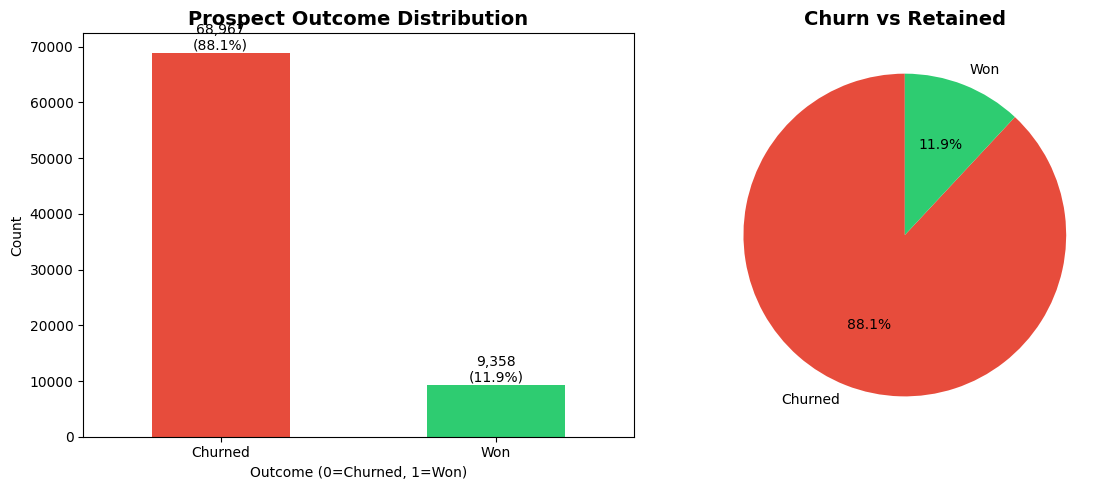

In [6]:
# 3a. Target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#e74c3c', '#2ecc71']
target_counts.plot(kind='bar', ax=axes[0], color=colors)
axes[0].set_title('Prospect Outcome Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Outcome (0=Churned, 1=Won)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Churned', 'Won'], rotation=0)
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 500, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=10)

# Proportional view
target_counts.plot(kind='pie', ax=axes[1], colors=colors, autopct='%1.1f%%',
                   labels=['Churned', 'Won'], startangle=90)
axes[1].set_title('Churn vs Retained', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

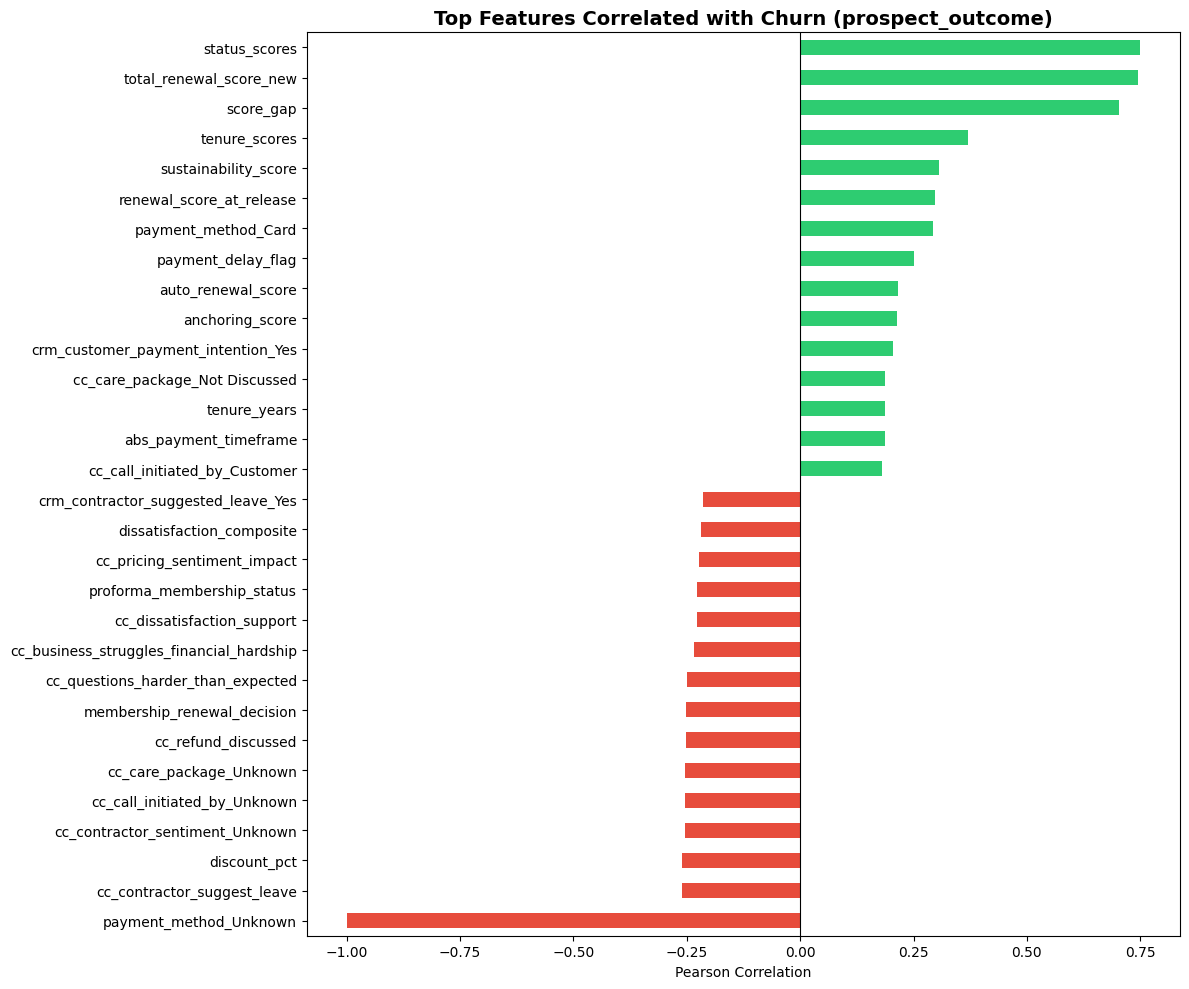


--- Top 15 Positive Correlations (associated with RETENTION) ---
  status_scores                                      +0.7500
  total_renewal_score_new                            +0.7445
  score_gap                                          +0.7023
  tenure_scores                                      +0.3711
  sustainability_score                               +0.3052
  renewal_score_at_release                           +0.2977
  payment_method_Card                                +0.2930
  payment_delay_flag                                 +0.2502
  auto_renewal_score                                 +0.2149
  anchoring_score                                    +0.2144
  crm_customer_payment_intention_Yes                 +0.2053
  cc_care_package_Not Discussed                      +0.1875
  tenure_years                                       +0.1874
  abs_payment_timeframe                              +0.1865
  cc_call_initiated_by_Customer                      +0.1808

--- Top 15 Negativ

In [7]:
# 3b. Top correlated features with target
df_analysis = df.copy()
for col in bool_cols:
    df_analysis[col] = df_analysis[col].astype(int)

# Remove non-numeric for correlation
corr_cols = df_analysis.select_dtypes(include=[np.number]).columns
correlations = df_analysis[corr_cols].corr()['prospect_outcome'].drop('prospect_outcome')
top_pos = correlations.sort_values(ascending=False).head(15)
top_neg = correlations.sort_values(ascending=True).head(15)
top_all = pd.concat([top_pos, top_neg]).drop_duplicates()

fig, ax = plt.subplots(figsize=(12, 10))
top_all_sorted = top_all.sort_values()
colors_bar = ['#e74c3c' if x < 0 else '#2ecc71' for x in top_all_sorted.values]
top_all_sorted.plot(kind='barh', ax=ax, color=colors_bar)
ax.set_title('Top Features Correlated with Churn (prospect_outcome)', fontsize=14, fontweight='bold')
ax.set_xlabel('Pearson Correlation')
ax.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print('\n--- Top 15 Positive Correlations (associated with RETENTION) ---')
for feat, corr in top_pos.items():
    print(f'  {feat:50s} {corr:+.4f}')

print('\n--- Top 15 Negative Correlations (associated with CHURN) ---')
for feat, corr in top_neg.items():
    print(f'  {feat:50s} {corr:+.4f}')

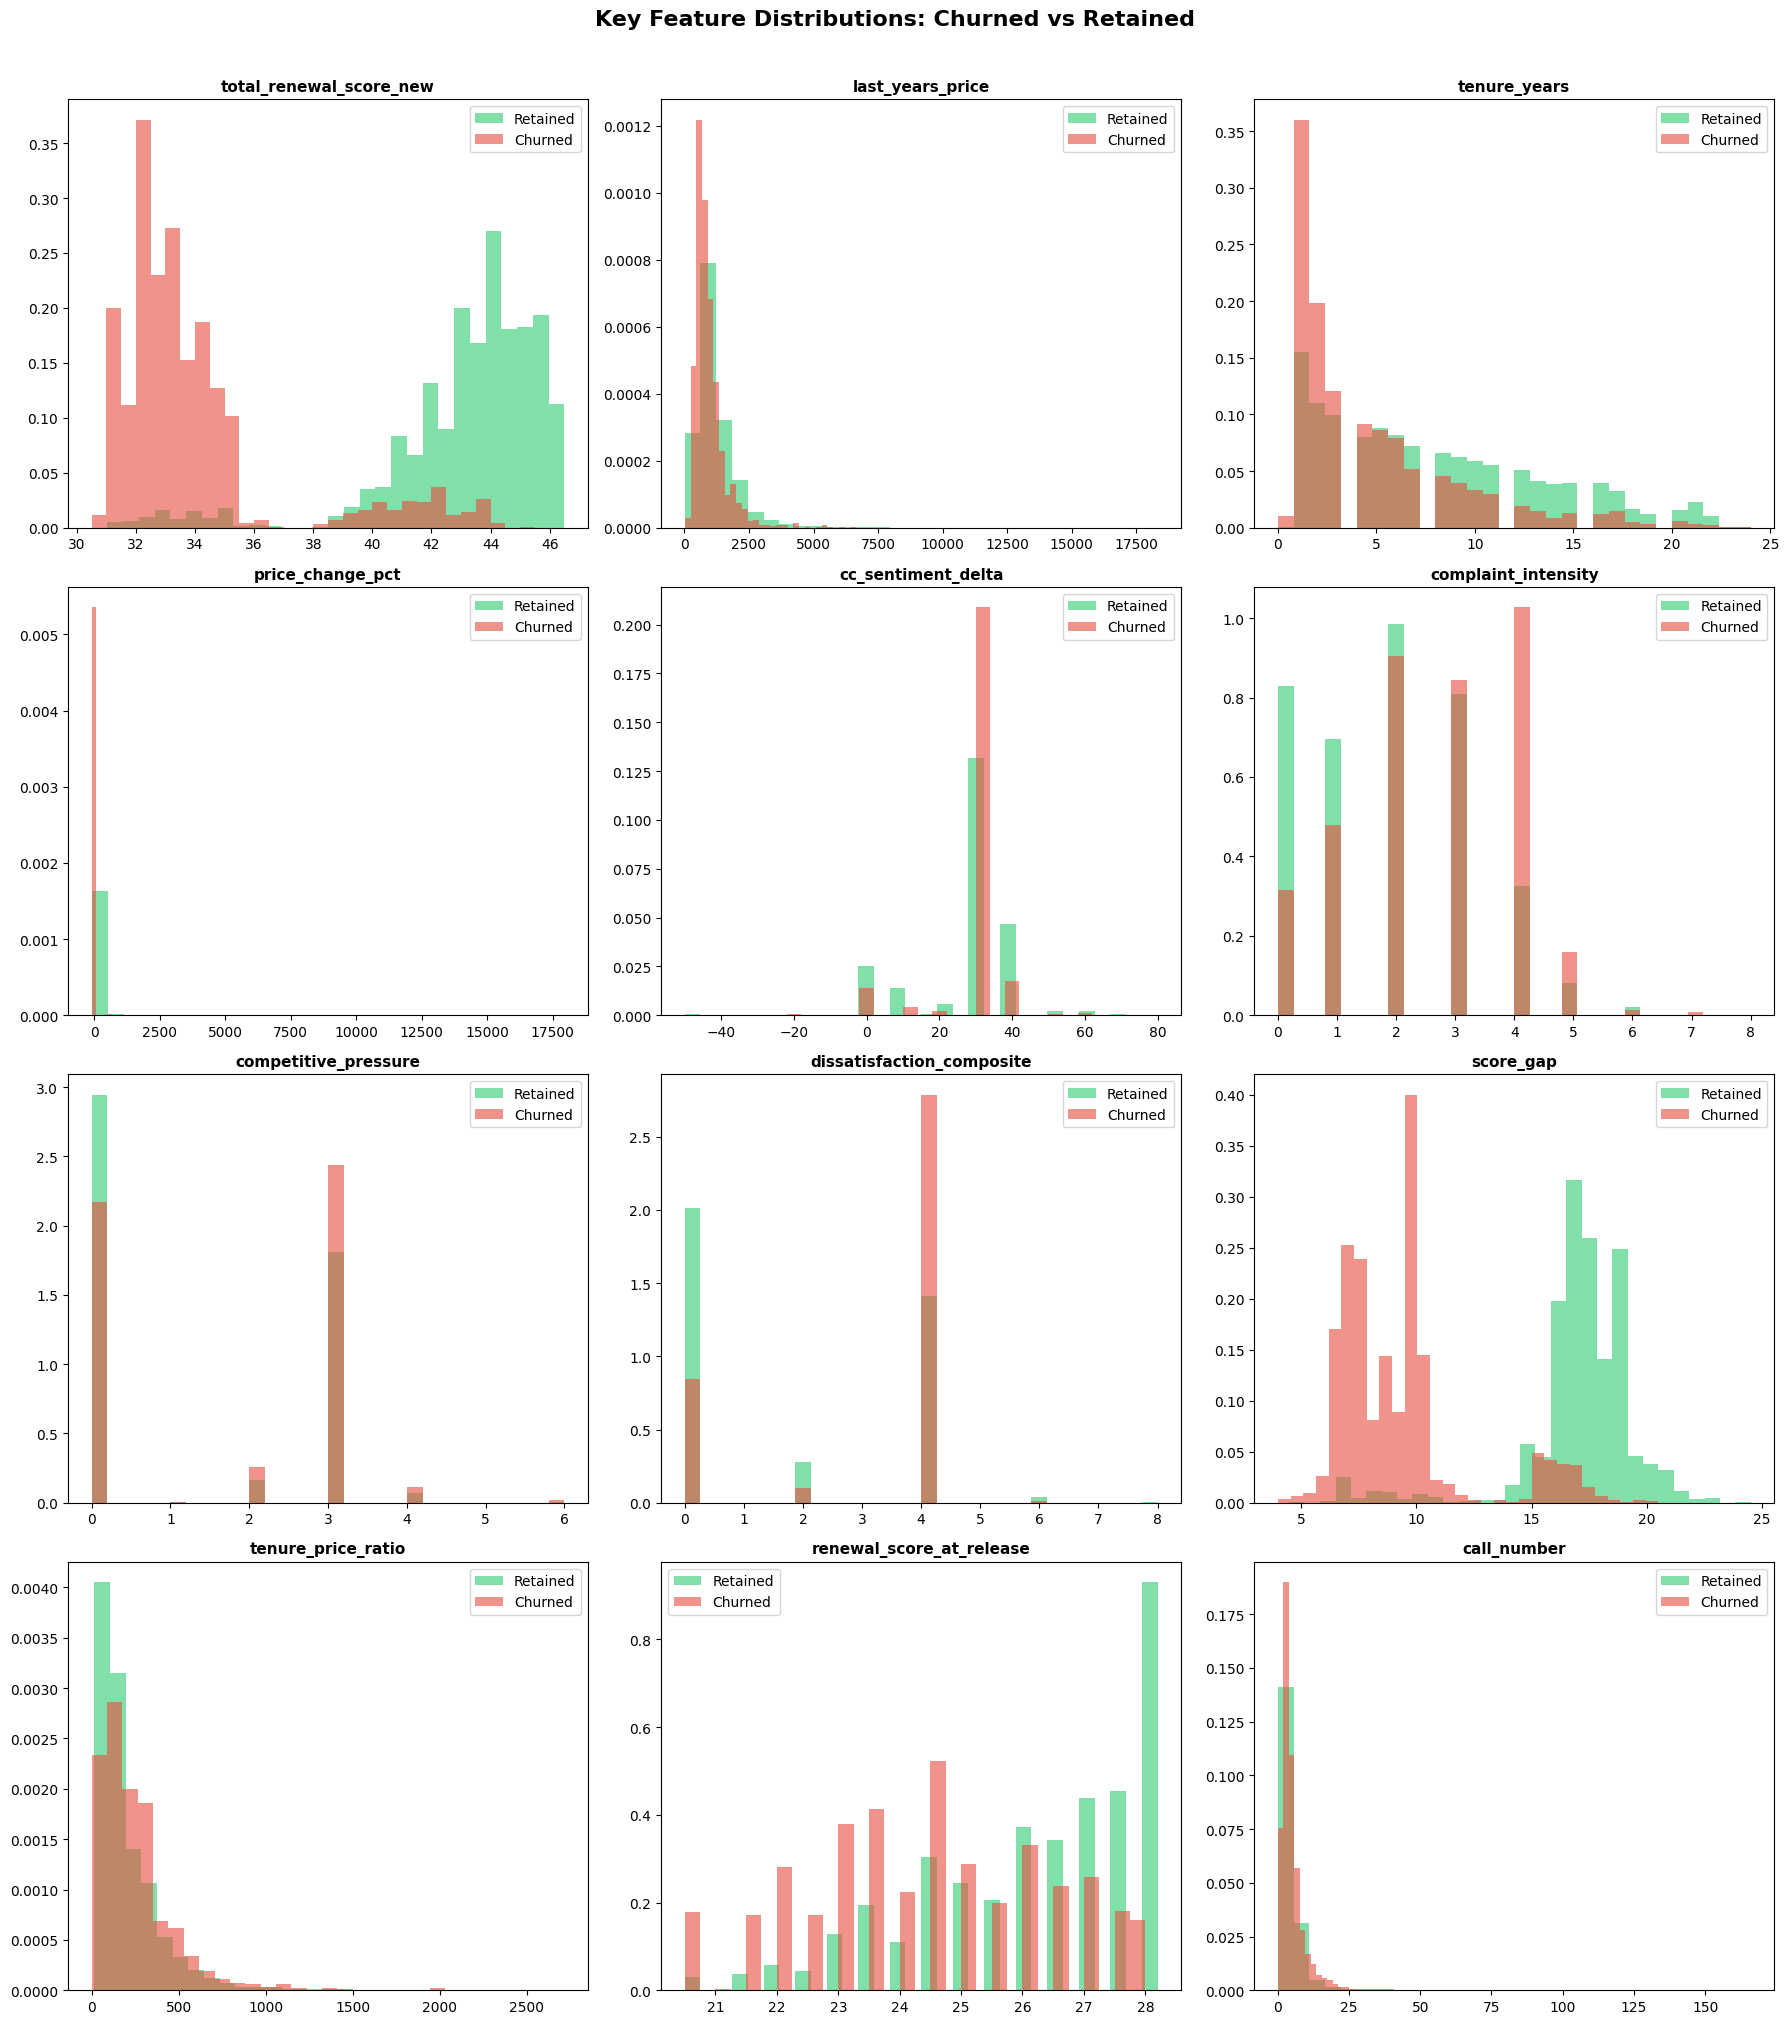

In [8]:
# 3c. Key numeric distributions by outcome
key_numeric = ['total_renewal_score_new', 'last_years_price', 'tenure_years',
               'price_change_pct', 'cc_sentiment_delta', 'complaint_intensity',
               'competitive_pressure', 'dissatisfaction_composite', 'score_gap',
               'tenure_price_ratio', 'renewal_score_at_release', 'call_number']

fig, axes = plt.subplots(4, 3, figsize=(18, 20))
axes = axes.flatten()
for i, col in enumerate(key_numeric):
    if col in df.columns:
        churned = df[df['prospect_outcome'] == 0][col].dropna()
        retained = df[df['prospect_outcome'] == 1][col].dropna()
        axes[i].hist(retained, bins=30, alpha=0.6, label='Retained', color='#2ecc71', density=True)
        axes[i].hist(churned, bins=30, alpha=0.6, label='Churned', color='#e74c3c', density=True)
        axes[i].set_title(col, fontsize=11, fontweight='bold')
        axes[i].legend()
plt.suptitle('Key Feature Distributions: Churned vs Retained', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

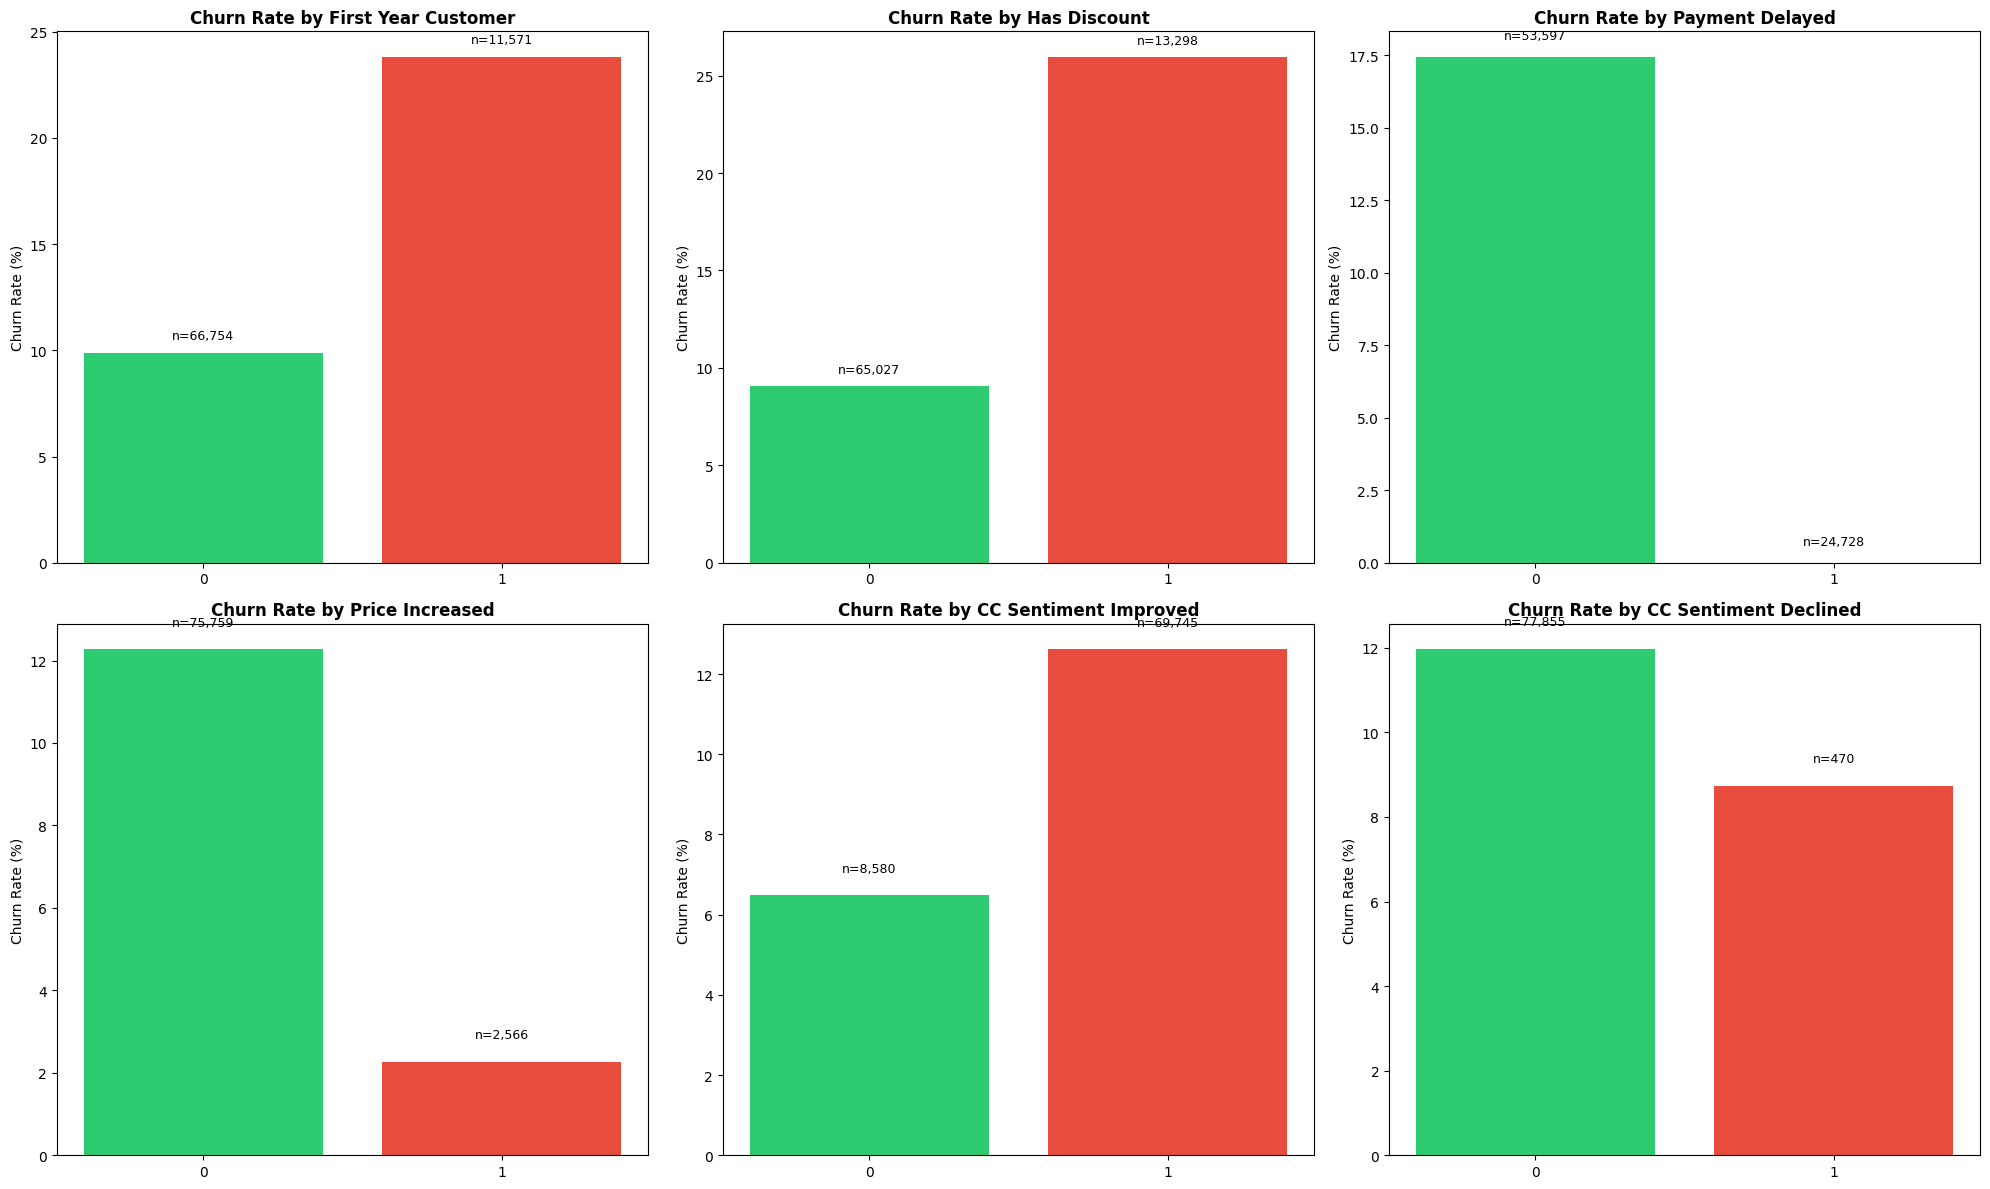

In [9]:
# 3d. Churn rates by categorical segments
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
segments = {
    'is_first_year': 'First Year Customer',
    'has_discount': 'Has Discount',
    'payment_delay_flag': 'Payment Delayed',
    'price_increase_flag': 'Price Increased',
    'cc_sentiment_improved': 'CC Sentiment Improved',
    'cc_sentiment_declined': 'CC Sentiment Declined'
}
for ax, (col, title) in zip(axes.flatten(), segments.items()):
    churn_by_seg = df.groupby(col)['prospect_outcome'].agg(['mean', 'count'])
    churn_by_seg['churn_rate'] = (1 - churn_by_seg['mean']) * 100
    bars = ax.bar(churn_by_seg.index.astype(str), churn_by_seg['churn_rate'], 
                  color=['#2ecc71', '#e74c3c'])
    ax.set_title(f'Churn Rate by {title}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Churn Rate (%)')
    for bar, count in zip(bars, churn_by_seg['count']):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                f'n={count:,}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

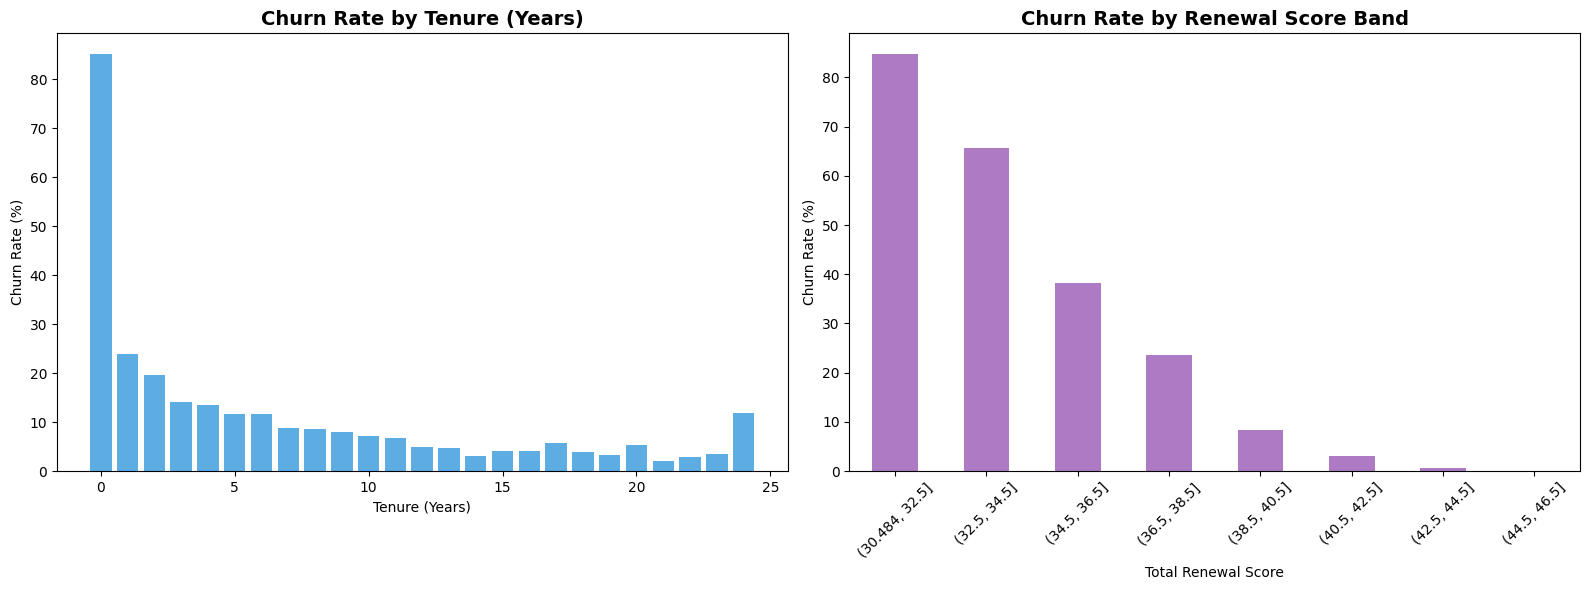

In [10]:
# 3e. Tenure vs Churn
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
tenure_churn = df.groupby('tenure_years')['prospect_outcome'].agg(['mean', 'count'])
tenure_churn['churn_rate'] = (1 - tenure_churn['mean']) * 100
axes[0].bar(tenure_churn.index, tenure_churn['churn_rate'], color='#3498db', alpha=0.8)
axes[0].set_title('Churn Rate by Tenure (Years)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Tenure (Years)')
axes[0].set_ylabel('Churn Rate (%)')

# Pricing bands
score_churn = df.groupby(pd.cut(df['total_renewal_score_new'], bins=8))['prospect_outcome'].mean()
score_churn_pct = (1 - score_churn) * 100
score_churn_pct.plot(kind='bar', ax=axes[1], color='#9b59b6', alpha=0.8)
axes[1].set_title('Churn Rate by Renewal Score Band', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Total Renewal Score')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

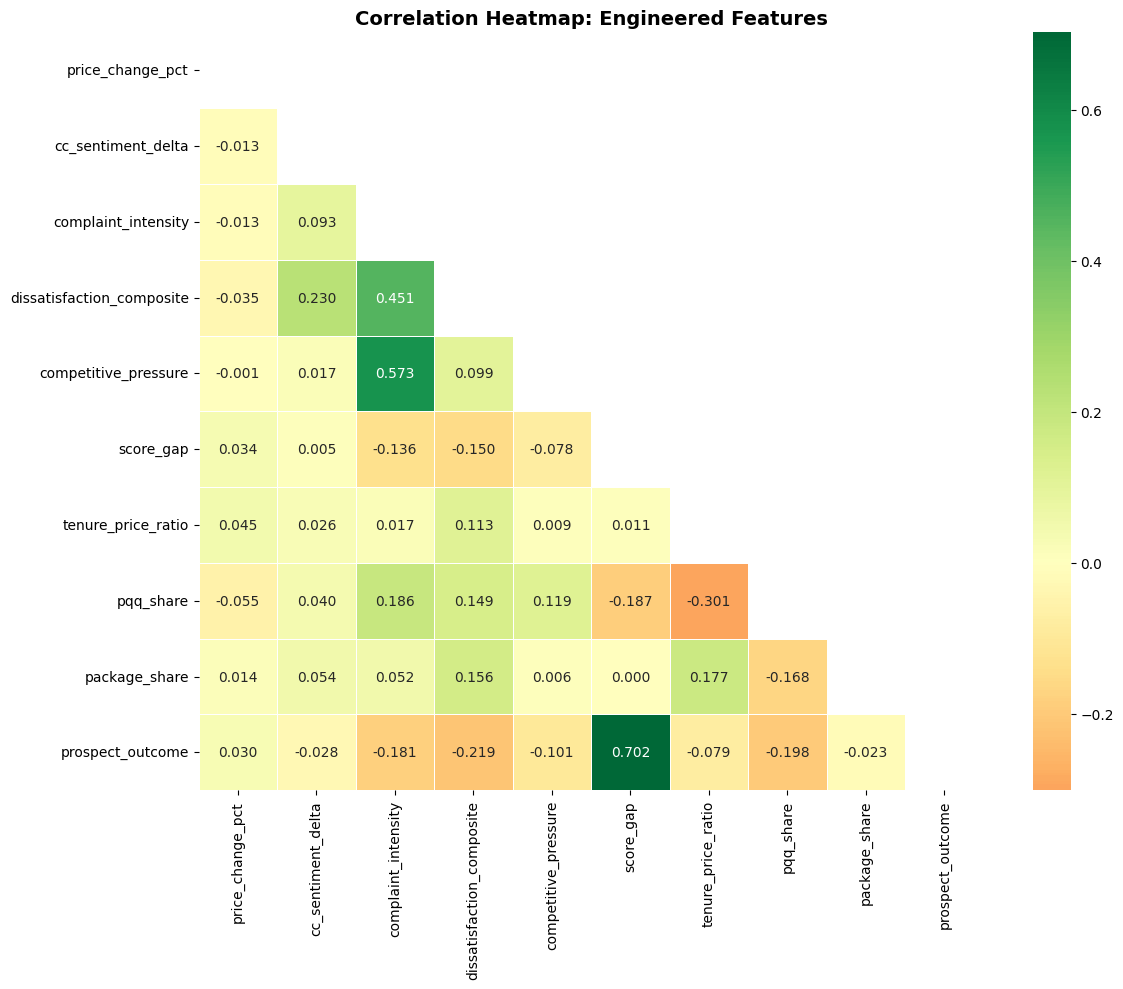

In [11]:
# 3f. Correlation heatmap of engineered features
engineered = ['price_change_pct', 'cc_sentiment_delta', 'complaint_intensity',
              'dissatisfaction_composite', 'competitive_pressure', 'score_gap',
              'tenure_price_ratio', 'pqq_share', 'package_share', 'prospect_outcome']
fig, ax = plt.subplots(figsize=(12, 10))
corr_matrix = df[engineered].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f', cmap='RdYlGn',
            center=0, ax=ax, linewidths=0.5)
ax.set_title('Correlation Heatmap: Engineered Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3.4 Hypothesis Testing & Validation

In [12]:
churned = df[df['prospect_outcome'] == 0]
retained = df[df['prospect_outcome'] == 1]

results = []

In [13]:
# H1: Higher renewal scores -> lower churn
print('\n--- H1: Higher total renewal scores are associated with lower churn ---')
stat, p = mannwhitneyu(churned['total_renewal_score_new'], retained['total_renewal_score_new'], alternative='two-sided')
print(f'  Mann-Whitney U: stat={stat:,.0f}, p={p:.2e}')
print(f'  Churned median: {churned["total_renewal_score_new"].median():.1f}')
print(f'  Retained median: {retained["total_renewal_score_new"].median():.1f}')
sig = 'SIGNIFICANT' if p < 0.05 else 'NOT SIGNIFICANT'
print(f'  Result: {sig} -> {"Supported" if p < 0.05 else "Not Supported"}')
results.append({'Hypothesis': 'H1: Higher renewal scores -> lower churn', 
                'Test': 'Mann-Whitney U', 'Statistic': stat, 'P-Value': p, 
                'Significant': p < 0.05, 'Conclusion': 'Supported' if p < 0.05 else 'Not Supported'})


--- H1: Higher total renewal scores are associated with lower churn ---
  Mann-Whitney U: stat=22,578,339, p=0.00e+00
  Churned median: 33.0
  Retained median: 44.0
  Result: SIGNIFICANT -> Supported


In [14]:
# H2: Price increases drive churn
print('\n--- H2: Price increases are associated with higher churn ---')
ct = pd.crosstab(df['price_increase_flag'], df['prospect_outcome'])
chi2, p, dof, expected = chi2_contingency(ct)
print(f'  Chi-Square: chi2={chi2:.2f}, p={p:.2e}, dof={dof}')
churn_increase = (df[df['price_increase_flag']==1]['prospect_outcome']==0).mean()*100
churn_no_increase = (df[df['price_increase_flag']==0]['prospect_outcome']==0).mean()*100
print(f'  Churn with price increase: {churn_increase:.2f}%')
print(f'  Churn without price increase: {churn_no_increase:.2f}%')
sig = 'SIGNIFICANT' if p < 0.05 else 'NOT SIGNIFICANT'
print(f'  Result: {sig}')
results.append({'Hypothesis': 'H2: Price increases -> higher churn',
                'Test': 'Chi-Square', 'Statistic': chi2, 'P-Value': p,
                'Significant': p < 0.05, 'Conclusion': 'Supported' if p < 0.05 and churn_increase > churn_no_increase else 'Not Supported'})


--- H2: Price increases are associated with higher churn ---
  Chi-Square: chi2=235.70, p=3.41e-53, dof=1
  Churn with price increase: 2.26%
  Churn without price increase: 12.28%
  Result: SIGNIFICANT


In [15]:
# H3: First-year customers churn more
print('\n--- H3: First-year customers have higher churn rates ---')
ct = pd.crosstab(df['is_first_year'], df['prospect_outcome'])
chi2, p, dof, expected = chi2_contingency(ct)
print(f'  Chi-Square: chi2={chi2:.2f}, p={p:.2e}, dof={dof}')
churn_fy = (df[df['is_first_year']==1]['prospect_outcome']==0).mean()*100
churn_nfy = (df[df['is_first_year']==0]['prospect_outcome']==0).mean()*100
print(f'  Churn rate (first year): {churn_fy:.2f}%')
print(f'  Churn rate (existing): {churn_nfy:.2f}%')
sig = 'SIGNIFICANT' if p < 0.05 else 'NOT SIGNIFICANT'
print(f'  Result: {sig}')
results.append({'Hypothesis': 'H3: First-year customers -> higher churn',
                'Test': 'Chi-Square', 'Statistic': chi2, 'P-Value': p,
                'Significant': p < 0.05, 'Conclusion': 'Supported' if p < 0.05 and churn_fy > churn_nfy else 'Not Supported'})


--- H3: First-year customers have higher churn rates ---
  Chi-Square: chi2=1817.16, p=0.00e+00, dof=1
  Churn rate (first year): 23.82%
  Churn rate (existing): 9.89%
  Result: SIGNIFICANT


In [16]:
# H4: Auto-renewal reduces churn
print('\n--- H4: Auto-renewal customers have lower churn ---')
ct = pd.crosstab(df['current_auto_renewal_flag'], df['prospect_outcome'])
chi2, p, dof, expected = chi2_contingency(ct)
print(f'  Chi-Square: chi2={chi2:.2f}, p={p:.2e}, dof={dof}')
churn_ar = (df[df['current_auto_renewal_flag']==1]['prospect_outcome']==0).mean()*100
churn_no_ar = (df[df['current_auto_renewal_flag']==0]['prospect_outcome']==0).mean()*100
print(f'  Churn rate (auto-renewal): {churn_ar:.2f}%')
print(f'  Churn rate (no auto-renewal): {churn_no_ar:.2f}%')
sig = 'SIGNIFICANT' if p < 0.05 else 'NOT SIGNIFICANT'
print(f'  Result: {sig}')
results.append({'Hypothesis': 'H4: Auto-renewal -> lower churn',
                'Test': 'Chi-Square', 'Statistic': chi2, 'P-Value': p,
                'Significant': p < 0.05, 'Conclusion': 'Supported' if p < 0.05 and churn_ar < churn_no_ar else 'Not Supported'})


--- H4: Auto-renewal customers have lower churn ---
  Chi-Square: chi2=2071.19, p=0.00e+00, dof=1


  Churn rate (auto-renewal): 10.49%
  Churn rate (no auto-renewal): 31.01%
  Result: SIGNIFICANT


In [17]:
# H5: Complaints -> higher churn
print('\n--- H5: Higher complaint intensity is associated with higher churn ---')
stat, p = mannwhitneyu(churned['complaint_intensity'], retained['complaint_intensity'], alternative='two-sided')
print(f'  Mann-Whitney U: stat={stat:,.0f}, p={p:.2e}')
print(f'  Churned mean complaint intensity: {churned["complaint_intensity"].mean():.3f}')
print(f'  Retained mean complaint intensity: {retained["complaint_intensity"].mean():.3f}')
sig = 'SIGNIFICANT' if p < 0.05 else 'NOT SIGNIFICANT'
print(f'  Result: {sig}')
results.append({'Hypothesis': 'H5: Higher complaints -> higher churn',
                'Test': 'Mann-Whitney U', 'Statistic': stat, 'P-Value': p,
                'Significant': p < 0.05, 'Conclusion': 'Supported' if p < 0.05 else 'Not Supported'})


--- H5: Higher complaint intensity is associated with higher churn ---
  Mann-Whitney U: stat=423,596,744, p=0.00e+00
  Churned mean complaint intensity: 2.630
  Retained mean complaint intensity: 1.850
  Result: SIGNIFICANT


In [18]:
# H6: Competitive pressure -> higher churn
print('\n--- H6: Competitive pressure (mentioning competitors) increases churn ---')
stat, p = mannwhitneyu(churned['competitive_pressure'], retained['competitive_pressure'], alternative='two-sided')
print(f'  Mann-Whitney U: stat={stat:,.0f}, p={p:.2e}')
print(f'  Churned mean competitive pressure: {churned["competitive_pressure"].mean():.3f}')
print(f'  Retained mean competitive pressure: {retained["competitive_pressure"].mean():.3f}')
sig = 'SIGNIFICANT' if p < 0.05 else 'NOT SIGNIFICANT'
print(f'  Result: {sig}')
results.append({'Hypothesis': 'H6: Competitive pressure -> higher churn',
                'Test': 'Mann-Whitney U', 'Statistic': stat, 'P-Value': p,
                'Significant': p < 0.05, 'Conclusion': 'Supported' if p < 0.05 else 'Not Supported'})


--- H6: Competitive pressure (mentioning competitors) increases churn ---
  Mann-Whitney U: stat=372,749,007, p=4.87e-172
  Churned mean competitive pressure: 1.679
  Retained mean competitive pressure: 1.217
  Result: SIGNIFICANT


In [19]:
# H7: CC Sentiment decline -> higher churn
print('\n--- H7: Declining CC sentiment (negative delta) is associated with churn ---')
stat, p = mannwhitneyu(churned['cc_sentiment_delta'], retained['cc_sentiment_delta'], alternative='two-sided')
print(f'  Mann-Whitney U: stat={stat:,.0f}, p={p:.2e}')
print(f'  Churned mean sentiment delta: {churned["cc_sentiment_delta"].mean():.3f}')
print(f'  Retained mean sentiment delta: {retained["cc_sentiment_delta"].mean():.3f}')
sig = 'SIGNIFICANT' if p < 0.05 else 'NOT SIGNIFICANT'
print(f'  Result: {sig}')
results.append({'Hypothesis': 'H7: Declining CC sentiment -> higher churn',
                'Test': 'Mann-Whitney U', 'Statistic': stat, 'P-Value': p,
                'Significant': p < 0.05, 'Conclusion': 'Supported' if p < 0.05 else 'Not Supported'})


--- H7: Declining CC sentiment (negative delta) is associated with churn ---
  Mann-Whitney U: stat=314,007,295, p=1.50e-06
  Churned mean sentiment delta: 28.582
  Retained mean sentiment delta: 27.450
  Result: SIGNIFICANT


In [20]:
# H8: Payment delays -> higher churn
print('\n--- H8: Payment delays are associated with higher churn ---')
ct = pd.crosstab(df['payment_delay_flag'], df['prospect_outcome'])
chi2, p, dof, expected = chi2_contingency(ct)
print(f'  Chi-Square: chi2={chi2:.2f}, p={p:.2e}, dof={dof}')
churn_delay = (df[df['payment_delay_flag']==1]['prospect_outcome']==0).mean()*100
churn_nodelay = (df[df['payment_delay_flag']==0]['prospect_outcome']==0).mean()*100
print(f'  Churn rate (delay): {churn_delay:.2f}%')
print(f'  Churn rate (no delay): {churn_nodelay:.2f}%')
sig = 'SIGNIFICANT' if p < 0.05 else 'NOT SIGNIFICANT'
print(f'  Result: {sig}')
results.append({'Hypothesis': 'H8: Payment delays -> higher churn',
                'Test': 'Chi-Square', 'Statistic': chi2, 'P-Value': p,
                'Significant': p < 0.05, 'Conclusion': 'Supported' if p < 0.05 and churn_delay > churn_nodelay else 'Not Supported'})


--- H8: Payment delays are associated with higher churn ---
  Chi-Square: chi2=4901.66, p=0.00e+00, dof=1


  Churn rate (delay): 0.00%
  Churn rate (no delay): 17.46%
  Result: SIGNIFICANT


In [21]:
# H9: Desire to cancel -> much higher churn
print('\n--- H9: Desire to cancel (from renewal calls) strongly predicts churn ---')
desire_col = 'desire_to_cancel_Not Discussed'
if desire_col in df.columns:
    ct = pd.crosstab(df[desire_col], df['prospect_outcome'])
    chi2, p, dof, expected = chi2_contingency(ct)
    print(f'  Chi-Square: chi2={chi2:.2f}, p={p:.2e}, dof={dof}')
    sig = 'SIGNIFICANT' if p < 0.05 else 'NOT SIGNIFICANT'
    print(f'  Result: {sig}')
    results.append({'Hypothesis': 'H9: Desire to cancel -> higher churn',
                    'Test': 'Chi-Square', 'Statistic': chi2, 'P-Value': p,
                    'Significant': p < 0.05, 'Conclusion': 'Supported' if p < 0.05 else 'Not Supported'})


--- H9: Desire to cancel (from renewal calls) strongly predicts churn ---
  Chi-Square: chi2=77.52, p=1.31e-18, dof=1
  Result: SIGNIFICANT


In [22]:
# H10: Discount offered -> reduces churn
print('\n--- H10: Discounts offered during calls reduce churn ---')
ct = pd.crosstab(df['has_discount'], df['prospect_outcome'])
chi2, p, dof, expected = chi2_contingency(ct)
print(f'  Chi-Square: chi2={chi2:.2f}, p={p:.2e}, dof={dof}')
churn_disc = (df[df['has_discount']==1]['prospect_outcome']==0).mean()*100
churn_nodisc = (df[df['has_discount']==0]['prospect_outcome']==0).mean()*100
print(f'  Churn rate (with discount): {churn_disc:.2f}%')
print(f'  Churn rate (no discount): {churn_nodisc:.2f}%')
sig = 'SIGNIFICANT' if p < 0.05 else 'NOT SIGNIFICANT'
print(f'  Result: {sig}')
results.append({'Hypothesis': 'H10: Discounts -> lower churn',
                'Test': 'Chi-Square', 'Statistic': chi2, 'P-Value': p,
                'Significant': p < 0.05, 'Conclusion': 'Supported' if p < 0.05 and churn_disc < churn_nodisc else 'Not Supported'})


--- H10: Discounts offered during calls reduce churn ---


  Chi-Square: chi2=2993.75, p=0.00e+00, dof=1


  Churn rate (with discount): 25.97%


  Churn rate (no discount): 9.08%
  Result: SIGNIFICANT


In [23]:
# H11: Tenure correlates with retention (Spearman)
print('\n--- H11: Tenure years positively correlates with retention ---')
rho, p = spearmanr(df['tenure_years'], df['prospect_outcome'])
print(f'  Spearman rho = {rho:.4f}, p = {p:.2e}')
sig = 'SIGNIFICANT' if p < 0.05 else 'NOT SIGNIFICANT'
print(f'  Result: {sig}')
results.append({'Hypothesis': 'H11: Tenure -> higher retention',
                'Test': 'Spearman Correlation', 'Statistic': rho, 'P-Value': p,
                'Significant': p < 0.05, 'Conclusion': 'Supported' if p < 0.05 and rho > 0 else 'Not Supported'})


--- H11: Tenure years positively correlates with retention ---
  Spearman rho = 0.2047, p = 0.00e+00
  Result: SIGNIFICANT


In [24]:
# H12: Financial hardship -> higher churn
print('\n--- H12: Financial hardship mentioned -> higher churn ---')
ct = pd.crosstab(df['cc_business_struggles_financial_hardship'], df['prospect_outcome'])
chi2, p, dof, expected = chi2_contingency(ct)
print(f'  Chi-Square: chi2={chi2:.2f}, p={p:.2e}, dof={dof}')
sig = 'SIGNIFICANT' if p < 0.05 else 'NOT SIGNIFICANT'
print(f'  Result: {sig}')
results.append({'Hypothesis': 'H12: Financial hardship -> higher churn',
                'Test': 'Chi-Square', 'Statistic': chi2, 'P-Value': p,
                'Significant': p < 0.05, 'Conclusion': 'Supported' if p < 0.05 else 'Not Supported'})


--- H12: Financial hardship mentioned -> higher churn ---
  Chi-Square: chi2=5155.25, p=0.00e+00, dof=2
  Result: SIGNIFICANT


In [25]:
# Print summary table
print('\n' + '='*80)
print('HYPOTHESIS TESTING SUMMARY')
print('='*80)
results_df = pd.DataFrame(results)
for _, row in results_df.iterrows():
    marker = '[Y]' if row['Significant'] else '[N]'
    print(f'  {marker} {row["Hypothesis"]}')
    print(f'      Test: {row["Test"]} | p-value: {row["P-Value"]:.2e} | {row["Conclusion"]}')
    print()


HYPOTHESIS TESTING SUMMARY
  [Y] H1: Higher renewal scores -> lower churn
      Test: Mann-Whitney U | p-value: 0.00e+00 | Supported

  [Y] H2: Price increases -> higher churn
      Test: Chi-Square | p-value: 3.41e-53 | Not Supported

  [Y] H3: First-year customers -> higher churn
      Test: Chi-Square | p-value: 0.00e+00 | Supported

  [Y] H4: Auto-renewal -> lower churn
      Test: Chi-Square | p-value: 0.00e+00 | Supported

  [Y] H5: Higher complaints -> higher churn
      Test: Mann-Whitney U | p-value: 0.00e+00 | Supported

  [Y] H6: Competitive pressure -> higher churn
      Test: Mann-Whitney U | p-value: 4.87e-172 | Supported

  [Y] H7: Declining CC sentiment -> higher churn
      Test: Mann-Whitney U | p-value: 1.50e-06 | Supported

  [Y] H8: Payment delays -> higher churn
      Test: Chi-Square | p-value: 0.00e+00 | Not Supported

  [Y] H9: Desire to cancel -> higher churn
      Test: Chi-Square | p-value: 1.31e-18 | Supported

  [Y] H10: Discounts -> lower churn
      Tes

## 3.5 Advanced EDA Insights

In [26]:
# 5a. Churn risk profile
print('\n--- CHURN RISK PROFILE ---')
print(f'  Overall churn rate: {(df["prospect_outcome"]==0).mean()*100:.2f}%')
print(f'  First-year customer churn: {churn_fy:.2f}%')
print(f'  Churned customers avg renewal score: {churned["total_renewal_score_new"].mean():.1f}')
print(f'  Retained customers avg renewal score: {retained["total_renewal_score_new"].mean():.1f}')
print(f'  Churned avg sentiment delta: {churned["cc_sentiment_delta"].mean():.1f}')
print(f'  Retained avg sentiment delta: {retained["cc_sentiment_delta"].mean():.1f}')
print(f'  Churned avg complaint intensity: {churned["complaint_intensity"].mean():.2f}')
print(f'  Retained avg complaint intensity: {retained["complaint_intensity"].mean():.2f}')

# 5b. Payment method churn rates
print('\n--- PAYMENT METHOD CHURN RATES ---')
payment_cols = [c for c in df.columns if c.startswith('payment_method_')]
for pc in payment_cols:
    subset = df[df[pc] == True]
    if len(subset) > 0:
        cr = (subset['prospect_outcome'] == 0).mean() * 100
        print(f'  {pc.replace("payment_method_", ""):15s}: {cr:.2f}% churn (n={len(subset):,})')


--- CHURN RISK PROFILE ---
  Overall churn rate: 11.95%
  First-year customer churn: 23.82%
  Churned customers avg renewal score: 33.7
  Retained customers avg renewal score: 43.1
  Churned avg sentiment delta: 28.6
  Retained avg sentiment delta: 27.4
  Churned avg complaint intensity: 2.63
  Retained avg complaint intensity: 1.85

--- PAYMENT METHOD CHURN RATES ---
  Card           : 0.00% churn (n=30,354)


  Cheque         : 0.00% churn (n=43)
  Unknown        : 100.00% churn (n=9,358)
  World Pay      : 0.00% churn (n=848)


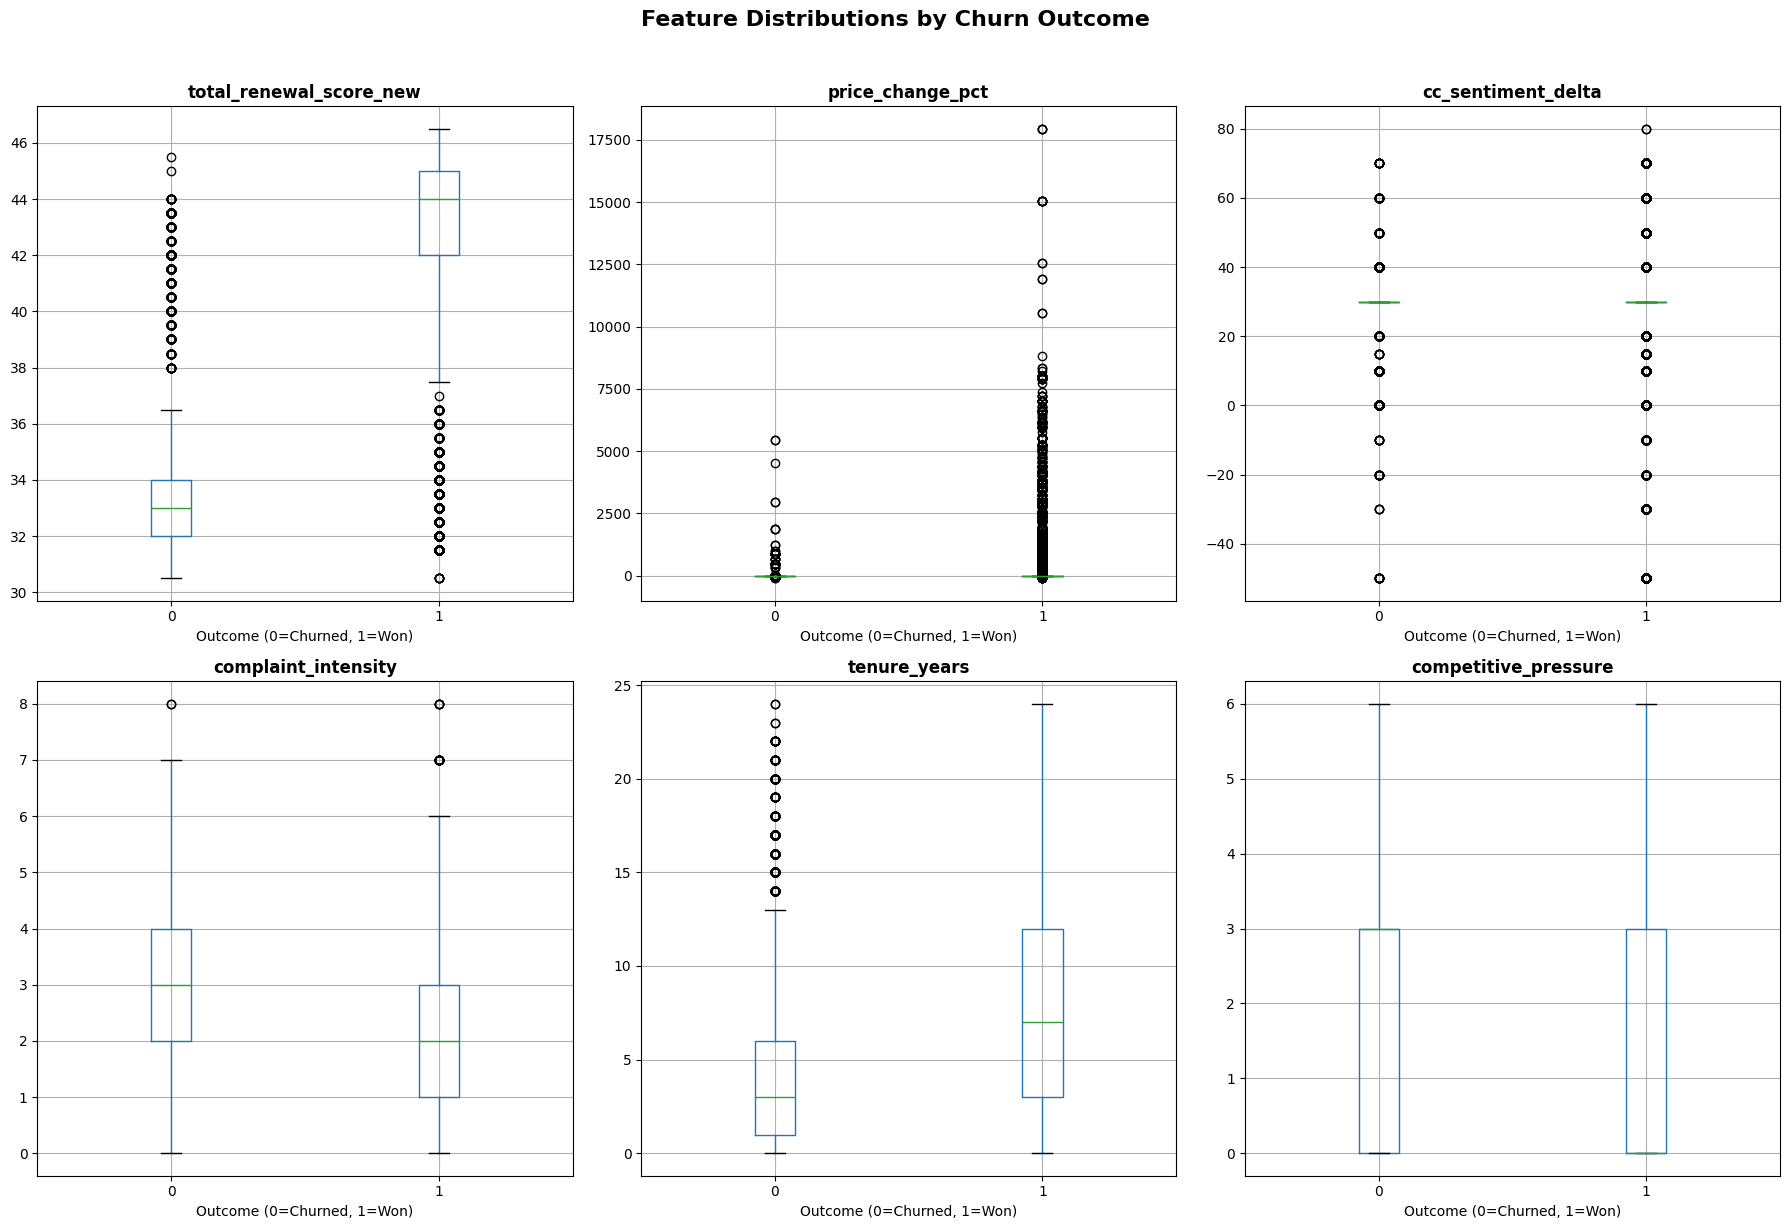

In [27]:
# 5c. Boxplots of key features
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
box_features = ['total_renewal_score_new', 'price_change_pct', 'cc_sentiment_delta',
                'complaint_intensity', 'tenure_years', 'competitive_pressure']
for ax, feat in zip(axes.flatten(), box_features):
    if feat in df.columns:
        df.boxplot(column=feat, by='prospect_outcome', ax=ax)
        ax.set_title(feat, fontsize=12, fontweight='bold')
        ax.set_xlabel('Outcome (0=Churned, 1=Won)')
plt.suptitle('Feature Distributions by Churn Outcome', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


--- CHURN BY PRICING TIER ---
  Low       : 20.57% churn (n=20,530)
  Mid-Low   : 11.28% churn (n=19,225)
  Mid-High  : 8.52% churn (n=20,209)
  High      : 6.78% churn (n=18,361)


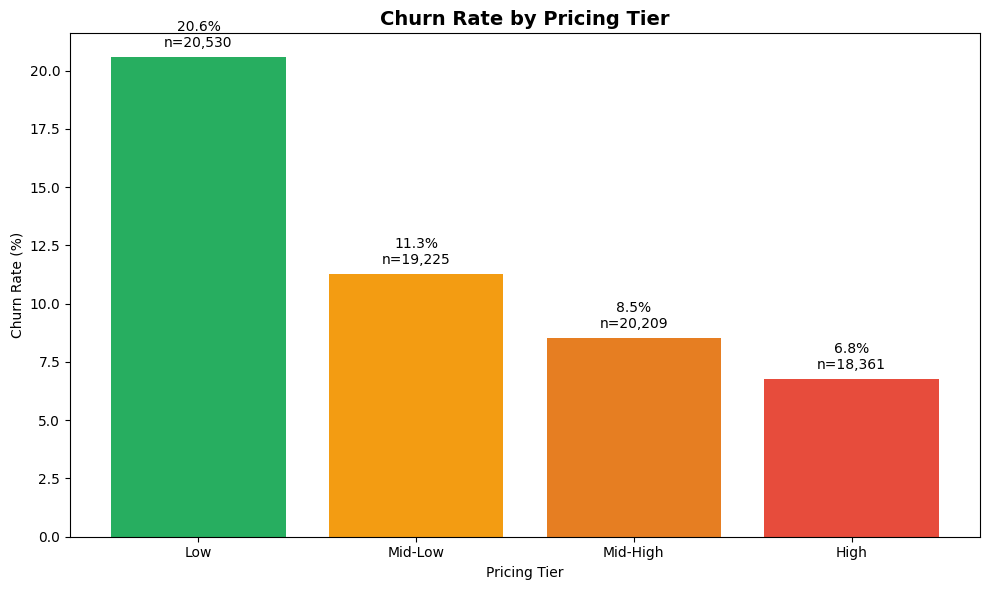

In [28]:
# 5d. Churn rate by pricing tier
print('\n--- CHURN BY PRICING TIER ---')
for tier in ['Low', 'Mid-Low', 'Mid-High', 'High']:
    subset = df[df['pricing_tier'] == tier]
    cr = (subset['prospect_outcome'] == 0).mean() * 100
    print(f'  {tier:10s}: {cr:.2f}% churn (n={len(subset):,})')

# Final plot: Churn rate by pricing tier
fig, ax = plt.subplots(figsize=(10, 6))
tier_churn = df.groupby('pricing_tier', observed=True)['prospect_outcome'].agg(['mean', 'count'])
tier_churn['churn_rate'] = (1 - tier_churn['mean']) * 100
bars = ax.bar(tier_churn.index.astype(str), tier_churn['churn_rate'], color=['#27ae60', '#f39c12', '#e67e22', '#e74c3c'])
ax.set_title('Churn Rate by Pricing Tier', fontsize=14, fontweight='bold')
ax.set_xlabel('Pricing Tier')
ax.set_ylabel('Churn Rate (%)')
for bar, (_, row) in zip(bars, tier_churn.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
            f'{row["churn_rate"]:.1f}%\nn={int(row["count"]):,}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()